In [7]:
import os
import collections
import random
from tqdm import tqdm
from typing import Tuple, Any, Optional
import copy

import gymnasium as gym
import numpy as np
import torch
import torch.nn.functional as F
from matplotlib import pyplot as plt

In [8]:
class PPO_Clip_Agent():
    """ Since the discrete actions have been redefined as {0,1} by env, we can simply represent the action by a number. """
    def __init__(self,
                 episode_recorder:object,
                 actor_network:torch.nn, 
                 critic_network:torch.nn,
                 actor_optimizer:torch.optim,
                 critic_optimizer:torch.optim,
                 gamma:float = 0.9,
                 advantage_lambda:float = 0.95,
                 clip_epsilon:float = 0.2, 
                 train_iters:int = 10, 
                 batch_size:int = 32,
                 device:torch.device = torch.device("cpu")
                 ) -> None:
        
        self.device = device
        self.episode_recorder = episode_recorder
        self.actor_network = actor_network
        self.critic_network = critic_network
        self.actor_optimizer = actor_optimizer
        self.critic_optimizer = critic_optimizer              
        self.clip_epsilon = clip_epsilon
        self.train_iters = train_iters
        self.batch_size = batch_size
        self.gamma = gamma
        self.advantage_lambda = advantage_lambda
        
    def get_action(self, obs:np.ndarray) -> int:
        obs = torch.tensor(obs, dtype = torch.float32).to(self.device)
        dist = self.actor_network(obs) # NN_outputs -softmax-> Action distribution
        dist = F.softmax(dist, dim = 0) 
        action_probs = torch.distributions.Categorical(dist)
        picked_action = action_probs.sample()
                       
        return picked_action.item()
    
    def calculate_log_prob(self, obs:torch.tensor, action:torch.tensor) -> torch.tensor:
        dist = F.softmax(self.actor_network(obs), dim=1)
        log_prob = torch.log(dist.gather(1, action))
        
        return log_prob
        
    
    def calculate_advantage(self, td_error:torch.tensor) -> torch.tensor:
        """ The advantage function is calculated by the TD error. """
        td_error = td_error.cpu().detach().numpy()
        advantage_list = []
        advantage = 0.0
        for delta in td_error[::-1]:
            advantage = self.gamma * self.advantage_lambda * advantage + delta
            advantage_list.append(advantage)
        advantage_list.reverse()
        advantage = torch.tensor(np.array(advantage_list), dtype = torch.float32).to(self.device)
        
        return advantage
    
    def train_policy(self) -> None:
        obs, action, reward, next_obs , done, = self.episode_recorder.get_trajectory()
        
        # Data preparation
        # 1. TD_target = r + gamma * V(s')
        TD_target = reward + self.gamma * self.critic_network(next_obs) * (1 - done)
        TD_error = TD_target - self.critic_network(obs)
        # 2. Advantage 
        advantage = self.calculate_advantage(TD_error)
        # 3. Log_prob
        old_log_prob = self.calculate_log_prob(obs,action).detach() # Freeze the log_prob obtained by the current policy
        # Update the policy by batch
        for _ in range(self.train_iters):
            sample_indices = np.random.randint(low=0,
                                            high=obs.shape[0],
                                            size=self.batch_size)
            
            critic_loss = torch.mean(F.mse_loss(TD_target[sample_indices].detach(), self.critic_network(obs[sample_indices])))
            self.critic_optimizer.zero_grad()
            critic_loss.backward()
            self.critic_optimizer.step()
            
            log_prob = self.calculate_log_prob(obs[sample_indices], action[sample_indices])
            ratio = torch.exp(log_prob - old_log_prob[sample_indices]) # pi_theta / pi_theta_old
            clipped_ratio = torch.clamp(ratio, 1-self.clip_epsilon, 1+self.clip_epsilon)
            actor_loss = torch.mean(-torch.min(ratio * advantage[sample_indices], clipped_ratio * advantage[sample_indices]))
            self.actor_optimizer.zero_grad()
            actor_loss.backward()
            self.actor_optimizer.step()


class Actor_Network(torch.nn.Module):

    def __init__(self,obs_dim:int,action_dim:int) -> None:
        super(Actor_Network, self).__init__()
        self.fc1 = torch.nn.Linear(obs_dim,64)
        self.fc2 = torch.nn.Linear(64,action_dim)
                    
    def forward(self,x:torch.tensor) -> torch.tensor:
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
                
        return x
    
class Critic_Network(torch.nn.Module):

    def __init__(self,obs_dim:int) -> None:
        super(Critic_Network, self).__init__()
        self.fc1 = torch.nn.Linear(obs_dim,64)
        self.fc2 = torch.nn.Linear(64,1)
                    
    def forward(self,x:torch.tensor) -> torch.tensor:
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
                
        return x
    

class Episode_Recorder():
    
    def __init__(self, device:torch.device = torch.device("cpu")) -> None:
        self.device = device
        self.reset()
        
    def append(self, 
               obs: np.ndarray,
               action: int,
               reward:float,
               next_obs: np.ndarray,
               done: bool
               ) -> None:
        obs = torch.tensor(np.array([obs]), 
                           dtype = torch.float32).to(self.device)
        action = torch.tensor(np.array([[action]]), 
                              dtype = torch.int64).to(self.device)
        reward = torch.tensor(np.array([[reward]]), 
                              dtype = torch.float32).to(self.device)
        next_obs = torch.tensor(np.array([next_obs]), 
                                dtype = torch.float32).to(self.device)
        done = torch.tensor(np.array([[done]]), 
                            dtype = torch.float32).to(self.device)
        self.trajectory["obs"] = torch.cat((self.trajectory["obs"], obs))
        self.trajectory["action"] = torch.cat((self.trajectory["action"], action))
        self.trajectory["reward"] = torch.cat((self.trajectory["reward"], reward))
        self.trajectory["next_obs"] = torch.cat((self.trajectory["next_obs"], next_obs))
        self.trajectory["done"] = torch.cat((self.trajectory["done"], done))
        
    def get_trajectory(self) -> Tuple[torch.tensor, torch.tensor, torch.tensor, torch.tensor, torch.tensor, torch.tensor]:
        
        return self.trajectory["obs"], self.trajectory["action"], \
            self.trajectory["reward"], self.trajectory["next_obs"], self.trajectory["done"]
    
    def reset(self) -> None:
        """ Clear the trajectory when begin a new episode."""
        self.trajectory = {
            "obs": torch.tensor([], dtype = torch.float32).to(self.device),
            "action": torch.tensor([], dtype = torch.int64).to(self.device),
            "reward": torch.tensor([], dtype = torch.float32).to(self.device),
            "next_obs": torch.tensor([], dtype = torch.float32).to(self.device),
            "done": torch.tensor([], dtype = torch.float32).to(self.device)
        }

In [9]:
class BC_Agent():
    """Behavioral Cloning Agent"""
    def __init__(self,
        input_dim:int,
        output_dim:int,
        policy_network:torch.nn.Module,
        optimizer:torch.optim.Optimizer,
        device:torch.device = torch.device("cpu")
    ) -> None: 
        self.input_dim = input_dim
        self.output_dim = output_dim
        self.policy_network = policy_network
        self.optimizer = optimizer
        self.device = device
        
    def predict(self, obs:np.ndarray)->torch.tensor:
        obs = torch.tensor(obs, dtype = torch.float32).to(self.device)
        dist = self.policy_network(obs)
        # action_probs = torch.distributions.Categorical(dist)
        # picked_action = action_probs.sample()
        picked_action = torch.argmax(dist)

        return picked_action
    
    def learn(self, 
        obs:torch.tensor, 
        action:torch.tensor
    ) -> None:
        log_prob = torch.log(self.policy_network(obs).gather(1, action.unsqueeze(-1)))
        loss = torch.mean(-log_prob)
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()
        
        
class Policy_Network(torch.nn.Module):
    def __init__(
        self,
        input_dim:int, 
        output_dim:int
    ) -> None:
        super(Policy_Network, self).__init__()
        self.fc1 = torch.nn.Linear(input_dim, 64)
        self.fc2 = torch.nn.Linear(64, output_dim)
        
    def forward(self, x:torch.tensor) -> torch.tensor:
        x = F.relu(self.fc1(x))
        return torch.softmax(self.fc2(x), dim=-1)

In [10]:
class ReplayBuffer():
    """Expert experience collector"""
    def __init__(
        self, 
        capacity:int, 
        device:torch.device = torch.device("cpu")
    ) -> None:
        self.device = device
        self.buffer = collections.deque(maxlen=capacity)
        
    def append(self,exp_data:tuple) -> None:
        self.buffer.append(exp_data)
        
    def sample(self,batch_size:int,shuffle:bool = True) -> Tuple[torch.tensor,torch.tensor]:
        if shuffle:
            self.buffer = random.sample(self.buffer,len(self.buffer))
        batch_size = min(batch_size, len(self.buffer)) # in case the buffer is not enough        
        mini_batch = random.sample(self.buffer,batch_size)
        obs_batch, action_batch = zip(*mini_batch)
        obs_batch = torch.tensor(np.array(obs_batch),dtype=torch.float32,device=self.device)
        action_batch = torch.tensor(np.array(action_batch),dtype=torch.int64,device=self.device) 
          
        return obs_batch, action_batch
    
    def fetch_all(self,shuffle:bool = True) -> Tuple[torch.tensor,torch.tensor]:
        if shuffle:
            self.buffer = random.sample(self.buffer,len(self.buffer))
        obs_batch, action_batch = zip(*self.buffer)
        obs_batch = torch.tensor(np.array(obs_batch),dtype=torch.float32,device=self.device)
        action_batch = torch.tensor(np.array(action_batch),dtype=torch.int64,device=self.device) 
          
        return obs_batch, action_batch
    
    def release(self) -> None:
        self.buffer.clear()
        
    def __len__(self) -> int:
        return len(self.buffer)

In [11]:
class TrainManager():
    def __init__(
        self,
        train_env:gym.Env,
        test_env:gym.Env,
        ppo_train_episode_num:int = 200,
        actor_lr:float = 1e-3,
        critic_lr:float = 1e-2,
        gamma:float = 0.9,
        advantage_lambda:float = 0.95,
        clip_epsilon:float = 0.2,
        ppo_train_iters:int = 10,
        ppo_batch_size:int = 32,
        bc_lr:float = 1e-3,
        bc_train_iters:int = 5,
        buffer_capacity:int = 1000000,
        bc_batch_size:int = 64,
        bc_train_epoch_num:int = 1000,
        test_iters:int = 10,
        device:torch.device = torch.device("cpu"),
        seed:Optional[int] = None
    ) -> None:
        # Envs
        self.train_env = train_env
        self.test_env = test_env
        obs_dim = gym.spaces.utils.flatdim(train_env.observation_space) 
        action_dim = train_env.action_space.n
        self.device = device
        # Seeds
        _,_ = self.train_env.reset(seed=seed) # Seed for training
        _,_ = self.test_env.reset(seed=seed+1) # Seed for testing
        random.seed(seed)
        torch.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        np.random.seed(seed)
        torch.backends.cudnn.deterministic = True
        # Expert PPO
        self.ppo_train_episode_num = ppo_train_episode_num
        episode_recorder = Episode_Recorder(device = self.device)
        actor_network = Actor_Network(obs_dim,action_dim).to(self.device)
        actor_optimizer = torch.optim.Adam(actor_network.parameters(),lr=actor_lr)
        critic_network = Critic_Network(obs_dim).to(self.device)
        critic_optimizer = torch.optim.Adam(critic_network.parameters(),lr=critic_lr)
        self.ppo_agent = PPO_Clip_Agent(episode_recorder = episode_recorder,
                                    actor_network = actor_network, 
                                    critic_network = critic_network,
                                    actor_optimizer = actor_optimizer,
                                    critic_optimizer = critic_optimizer,
                                    gamma = gamma,
                                    advantage_lambda = advantage_lambda,
                                    clip_epsilon = clip_epsilon,
                                    train_iters = ppo_train_iters,
                                    batch_size = ppo_batch_size,
                                    device = self.device
                                    )
        # BC
        self.bc_train_epoch_num = bc_train_epoch_num
        self.bc_train_iters = bc_train_iters                                    
        self.buffer = ReplayBuffer(capacity=buffer_capacity, device=self.device)
        self.bc_batch_size = bc_batch_size
        self.test_iters = test_iters
        policy_network = Policy_Network(obs_dim, action_dim).to(self.device)
        bc_optimizer = torch.optim.Adam(policy_network.parameters(), lr=bc_lr)
        self.bc_agent = BC_Agent(
            input_dim = obs_dim, output_dim = action_dim,
            policy_network = policy_network, optimizer = bc_optimizer
        )
        
        self.test_returns_mean = []
        self.test_returns_max = []
        self.test_returns_min = []
         
        pass

    def train_ppo(self) -> None:
        self.episode_total_rewards = np.zeros(self.ppo_train_episode_num)
        self.index_episode = 0
        with tqdm(total=self.ppo_train_episode_num, desc='ExpertPPO_Training') as pbar:
            for _ in range(self.ppo_train_episode_num):
                episode_reward = self.train_ppo_episode()
                pbar.set_postfix({"Return": (episode_reward)})
                pbar.update(1)
        
    def train_ppo_episode(self) -> float:
        total_reward = 0
        self.ppo_agent.episode_recorder.reset()
        obs,_ = self.train_env.reset() 
        while True:
            action = self.ppo_agent.get_action(obs) 
            next_obs, reward, terminated, truncated, _ = self.train_env.step(action)
            done = terminated or truncated
            self.ppo_agent.episode_recorder.append(obs, action, reward, next_obs, done)
            total_reward += reward 
            obs = next_obs              
            if done:
                self.episode_total_rewards[self.index_episode] = total_reward
                self.index_episode += 1
                break
        
        self.ppo_agent.train_policy()
        
        return total_reward

    def train_DAgger(self) -> None:
        # Train the BC agent for 'bc_train_episode_num' epochs
        with tqdm(total=self.bc_train_epoch_num, desc='DAgger_Training') as pbar:
            for _ in range(self.bc_train_epoch_num):
                self.train_DAgger_episode()
                r_mean,r_max,r_min = self.DAgger_test()
                self.test_returns_mean.append(r_mean)
                self.test_returns_max.append(r_max)
                self.test_returns_min.append(r_min)
                pbar.set_postfix({"Avg.Return": (r_mean)})
                pbar.update(1)
    
    def train_DAgger_episode(self) -> None:
        # Sample a batch (of size = 'size') of expert data (idx from 0 to 'high'), allowing for replacement
        # Optimize for 'bc_train_iters' iterations
        
        state,_ = self.train_env.reset()
        done = False
        while not done:
            action = self.ppo_agent.get_action(state)
            next_state, _, terminated, truncated, _ = self.train_env.step(action)
            done = terminated or truncated
            self.buffer.append((state, action))
            state = next_state
        
        for _ in range(self.bc_train_iters):
            obs_all, action_all = self.buffer.fetch_all()
            sample_indices = np.random.randint(low=0,
                                high=obs_all.shape[0],
                                size=self.bc_batch_size)
            self.bc_agent.learn(obs_all[sample_indices], action_all[sample_indices])
    
    def DAgger_test(self) -> Tuple[float, float, float]:
        return_list = []
        for _ in range(self.test_iters):
            obs, _ = self.test_env.reset()
            done = False
            episode_return = 0
            while not done:
                action = int(self.bc_agent.predict(obs).item())
                next_obs, reward, terminated, truncated, _ = self.test_env.step(action)
                done = terminated or truncated
                obs = next_obs
                episode_return += reward
                
            return_list.append(episode_return)
            
        return np.mean(return_list), np.max(return_list), np.min(return_list)

In [12]:
# To make the test fair, we use two split environments with different seeds.
train_env = gym.make('CartPole-v0')
test_env = gym.make('CartPole-v0')

Manger = TrainManager(
        train_env =  train_env,
        test_env = test_env,
        ppo_train_episode_num = 1000,
        actor_lr = 1e-3,
        critic_lr = 5e-3,
        gamma = 0.98,
        advantage_lambda = 0.95,
        clip_epsilon = 0.2,
        ppo_train_iters = 5,
        ppo_batch_size = 64,
        bc_lr = 1e-3,
        bc_train_iters = 5,
        bc_batch_size = 32,
        bc_train_epoch_num = 500,
        buffer_capacity = 1000000,
        test_iters = 10,
        device = torch.device("cpu"),
        seed = 0,
)
# 1. --- Train PPO to collect expert (s,a) pairs ---
Manger.train_ppo()

# 2. --- Train BC using the expert data ---
Manger.train_DAgger() # train BC using data in buffer

/home/zhura/miniconda3/envs/torch/lib/python3.8/site-packages/gymnasium/envs/registration.py:523: DeprecationWarning: WARN: The environment CartPole-v0 is out of date. You should consider upgrading to version `v1`.
  logger.deprecation(
DAgger_Training: 100%|██████████| 500/500 [06:16<00:00,  1.33it/s, Avg.Return=200]


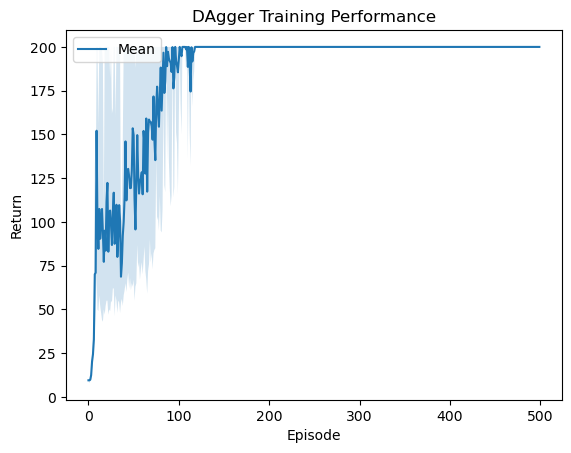

In [13]:
iteration_list = list(range(len(Manger.test_returns_mean)))
plt.plot(iteration_list, Manger.test_returns_mean, label='Mean')
plt.fill_between(iteration_list, Manger.test_returns_min, Manger.test_returns_max, alpha=0.2)
plt.legend()
plt.xlabel('Episode')
plt.ylabel('Return')
plt.title('DAgger Training Performance')
plt.show()